# Excercise 3 

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import lasio
import rockphypy as rp
from rockphypy import GM, EM

### Read data

In [22]:
from pathlib import Path

# Robust path handling: try workspace-relative and absolute paths
possible_paths = [
    Path("Excerise_1") / "Datasets" / "Formation Tops.xlsx",
    Path("./Excerise_1") / "Datasets" / "Formation Tops.xlsx",
    Path("/workspaces/well_data_preprocessing/Excerise_1/Datasets/Formation Tops.xlsx")
]

tops_path = None
for p in possible_paths:
    if p.exists():
        tops_path = p
        break

if tops_path is None:
    raise FileNotFoundError(
        "Could not find 'Formation Tops.xlsx'. Expected one of: " +
        ", ".join(str(p) for p in possible_paths)
    )

df_tops = pd.read_excel(tops_path)
df_tops["Top depth [mMD_RKB]"] = df_tops["Top depth [mMD_RKB]"].astype("float64")

display(df_tops.head())
print("Loaded tops from:", tops_path)

,Well #,Formation,Top depth [mMD_RKB]
0,XX-X,FM-1,406.0
1,XX-X,FM-2,478.0
2,XX-X,FM-3,639.0
3,XX-X,FM-4,674.0
4,XX-X,FM-5,702.0


Loaded tops from: /workspaces/well_data_preprocessing/Excerise_1/Datasets/Formation Tops.xlsx


### Get FM-10 top and base (using top of FM-11 as base)


In [23]:
z_top10 = float(df_tops.loc[df_tops["Formation"]=="FM-10", "Top depth [mMD_RKB]"].iloc[0])
z_top11 = float(df_tops.loc[df_tops["Formation"]=="FM-11", "Top depth [mMD_RKB]"].iloc[0])
z0, z1 = z_top10, z_top11

print(f"FM-10 interval (mMD_RKB): {z0:.2f} to {z1:.2f}")

FM-10 interval (mMD_RKB): 1517.00 to 2141.00


In [24]:
z_top10 = float(df_tops.loc[df_tops["Formation"]=="FM-10", "Top depth [mMD_RKB]"].iloc[0])
z_top11 = float(df_tops.loc[df_tops["Formation"]=="FM-11", "Top depth [mMD_RKB]"].iloc[0])
z0, z1 = z_top10, z_top11

print(f"FM-10 interval (mMD_RKB): {z0:.2f} to {z1:.2f}")

FM-10 interval (mMD_RKB): 1517.00 to 2141.00


### Creating path for well data LAS-file

In [25]:
possible_las_paths = [
    Path("Excerise_1") / "Datasets" / "Well Log.LAS",
    Path("./Excerise_1") / "Datasets" / "Well Log.LAS",
    Path("/workspaces/well_data_preprocessing/Excerise_1/Datasets/Well Log.LAS"),
    Path("/mnt/data/Well Log.LAS"),
]

las_path = None
for p in possible_las_paths:
    if p.exists():
        las_path = p
        break

if las_path is None:
    raise FileNotFoundError(
        "Could not find 'Well Log.LAS'. Expected one of:\n" +
        "\n".join(str(p) for p in possible_las_paths)
    )

las = lasio.read(las_path)
df_logs = las.df()
df_logs = df_logs.replace(-999.25, np.nan)
df_logs.index.name = "DEPT"
df_logs.head()

display(df_logs.head())
print("Loaded LAS from:", las_path)
print("Curves:", list(df_logs.columns))


,AC,ACS,BS,CALI,DEN,DENC,GR,K,NEU,PEF,RDEP,RMED,RMIC,ROP,TH,U
DEPT,,,,,,,,,,,,,,,,
405.9936,NaN,NaN,26.0,NaN,NaN,NaN,78.5885,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
406.1460,NaN,NaN,26.0,NaN,NaN,NaN,84.2673,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
406.2984,NaN,NaN,26.0,NaN,NaN,NaN,83.9706,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
406.4508,NaN,NaN,26.0,NaN,NaN,NaN,83.9938,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
406.6032,NaN,NaN,26.0,NaN,NaN,NaN,76.8121,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Loaded LAS from: /workspaces/well_data_preprocessing/Excerise_1/Datasets/Well Log.LAS
Curves: ['AC', 'ACS', 'BS', 'CALI', 'DEN', 'DENC', 'GR', 'K', 'NEU', 'PEF', 'RDEP', 'RMED', 'RMIC', 'ROP', 'TH', 'U']


In [26]:
df_logs = df_logs.loc[1517.00:2141.00]

In [27]:
# --- Velocity from sonic (AC, ACS in us/ft) -> m/s ---
# V = (1e6 / slowness_us_per_ft) * 0.3048
df_logs["Vp"] = (1e6 / df_logs["AC"])  * 0.3048
df_logs["Vs"] = (1e6 / df_logs["ACS"]) * 0.3048

# --- Porosity ---
# Keep density in g/cc (DEN is usually g/cc in LAS)∏
rho_ma = 2.65 # g/cc (quartz-ish)
rho_f  = 1.00 # g/cc (brine-ish)

df_logs["phi_D"] = (rho_ma - df_logs["DEN"]) / (rho_ma - rho_f)  # v/v
df_logs["phi_N"] = df_logs["NEU"]                               # usually v/v
df_logs["phi"]   = df_logs[["phi_D","phi_N"]].mean(axis=1)

# Clip to physical range
df_logs.loc[(df_logs["phi"] < 0) | (df_logs["phi"] > 0.60), "phi"] = np.nan

# --- Bulk modulus K [GPa] using rho in g/cc and V in m/s ---
# K[GPa] = 1e-3 * rho(g/cc) * (Vp^2 - 4/3 Vs^2)
df_logs["Kbulk_GPa"] = 1e-6 * df_logs["DEN"] * (df_logs["Vp"]**2 - (4.0/3.0)*df_logs["Vs"]**2)

# density to SI
df_logs["rho_kgm3"] = df_logs["DEN"] * 1000.0

# AI = rho * Vp
df_logs["AI"] = df_logs["rho_kgm3"] * df_logs["Vp"]

# shear modulus (Pa)
df_logs["Mu_Pa"] = df_logs["rho_kgm3"] * (df_logs["Vs"]**2)

# convert
df_logs["Mu_GPa"] = df_logs["Mu_Pa"] / 1e9

# Basic sanity stats
display(df_logs[["Vp","Vs","DEN","phi","Kbulk_GPa", "Mu_GPa", "GR"]].describe())


,Vp,Vs,DEN,phi,Kbulk_GPa,Mu_GPa,GR
count,4094.000000,4094.000000,4094.000000,4094.000000,4094.000000,4094.000000,4094.000000
mean,3478.173586,1814.533295,2.556444,0.126831,19.662383,8.576524,102.219105
std,270.430327,273.601391,0.062794,0.020055,2.607983,2.470717,13.798022
min,2841.256007,1221.709881,2.268100,0.036571,10.557253,3.820694,56.438500
25%,3286.237431,1597.157413,2.544525,0.113687,18.123240,6.602547,95.165225
50%,3488.477894,1813.279796,2.575300,0.125989,19.581398,8.508212,105.053700
75%,3649.243961,2001.525120,2.595600,0.139511,21.203096,10.228459,112.244975
max,4881.470591,2909.340817,2.663900,0.228842,36.238750,22.439610,155.383500


---

In [28]:
# --- vCem: cement volume from density ---
# Assumes: quartz grain (2.65), calcite cement (2.71), brine fluid (1.00)
rho_cem = 2.71   # g/cc  calcite
rho_ma  = 2.65   # g/cc  quartz
rho_f   = 1.00   # g/cc  brine

# vCem estimated as excess density above quartz framework
df_logs["vCem"] = (df_logs["DEN"] - rho_ma) / (rho_cem - rho_ma)
df_logs["vCem"] = df_logs["vCem"].clip(0, 1)

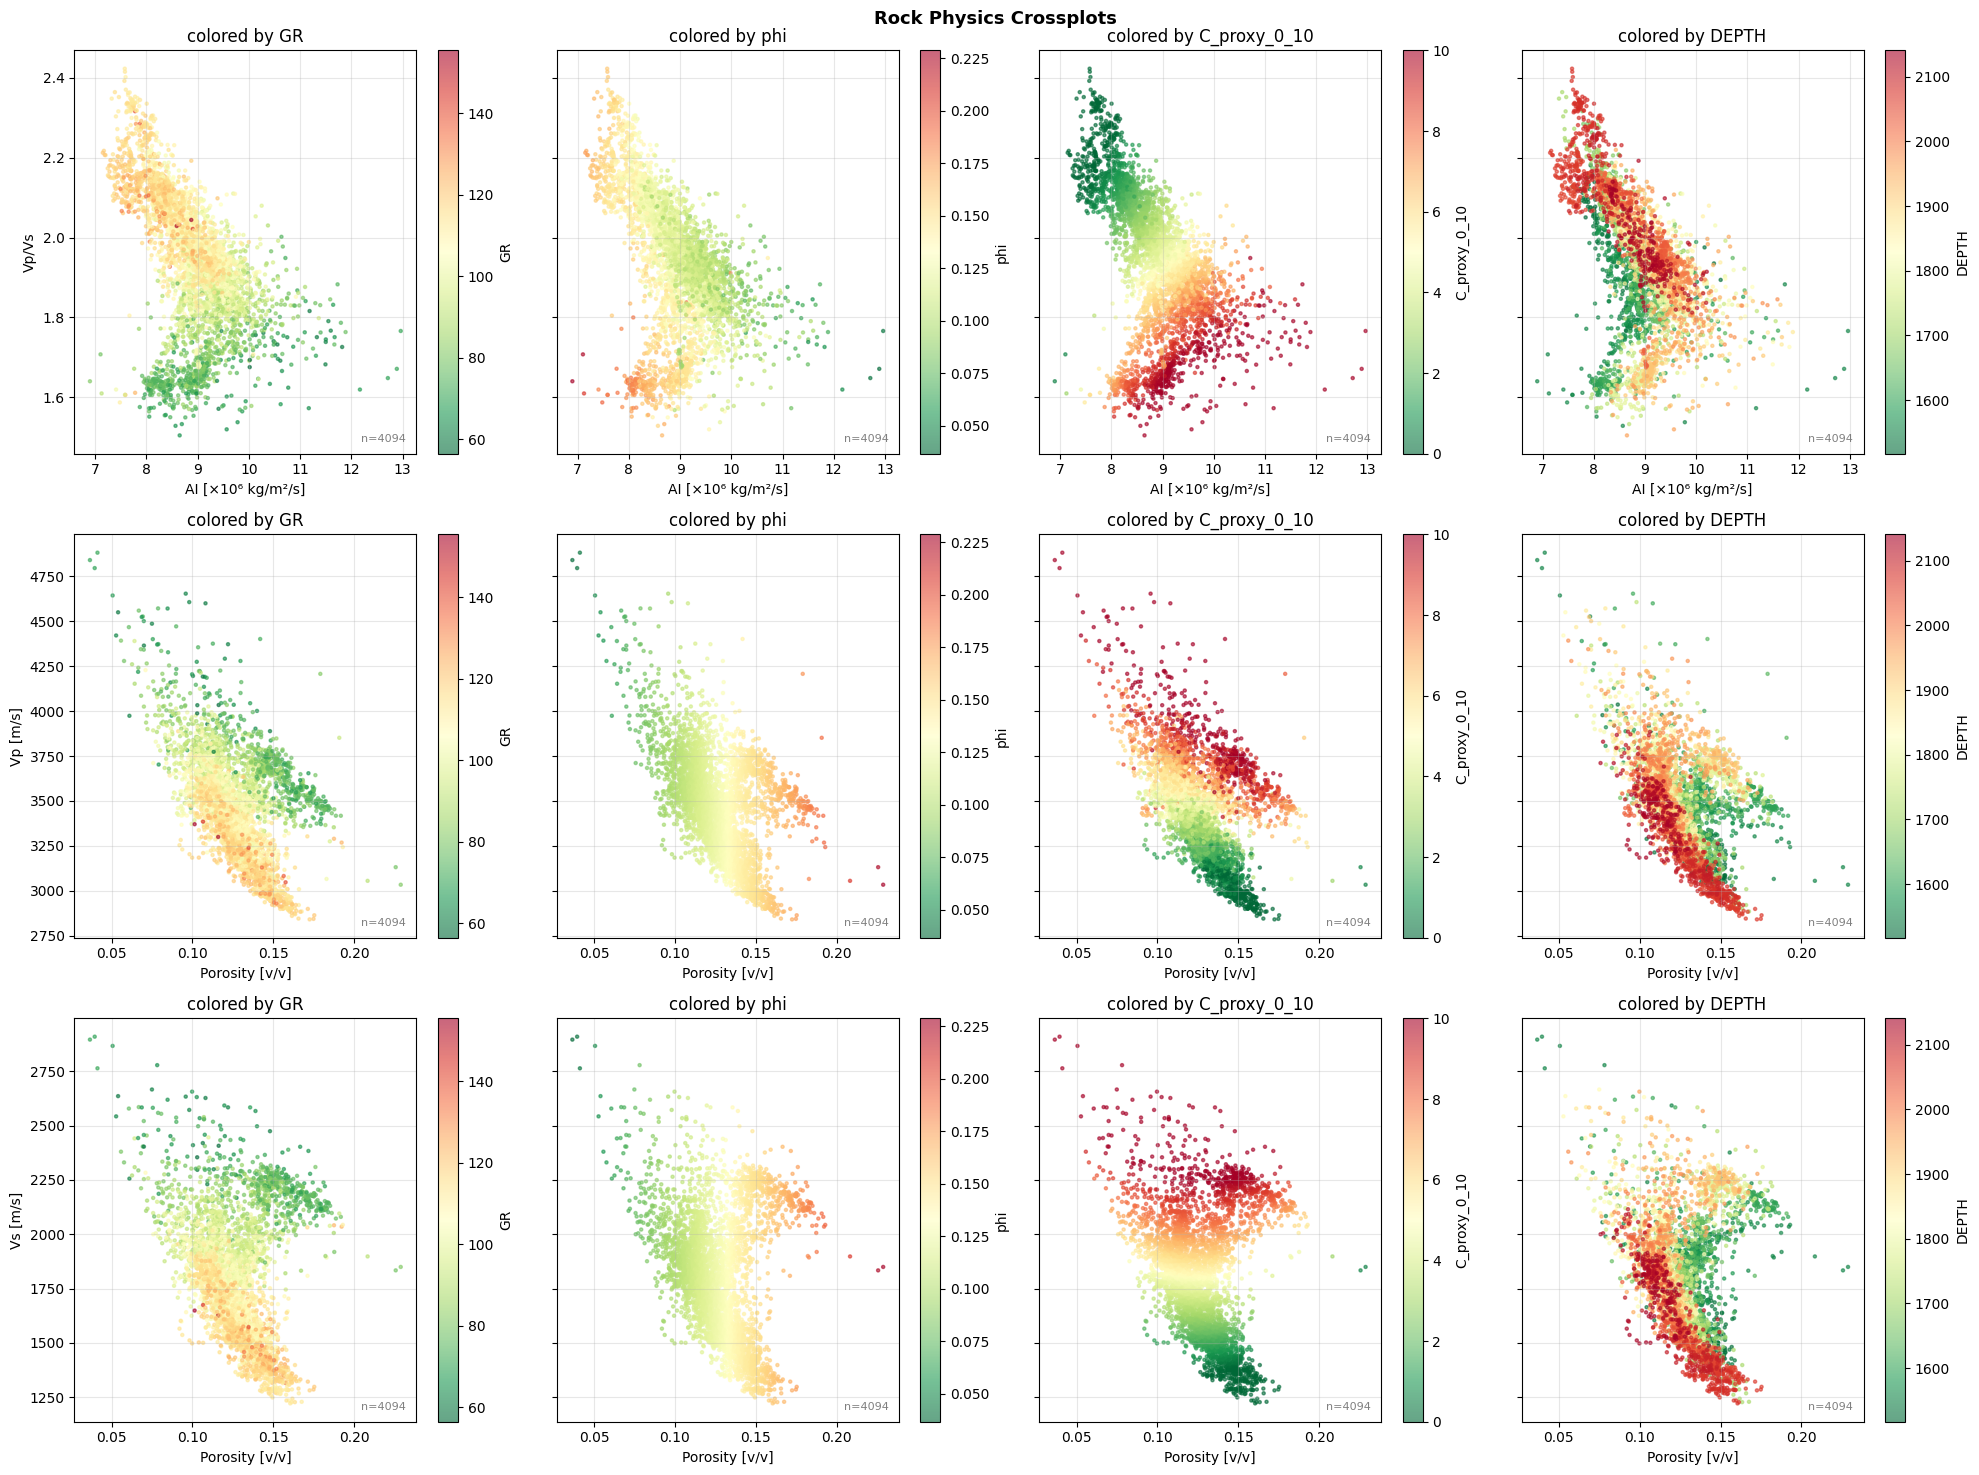

In [29]:
# --- C_cement: Vs-residual cement proxy ---
gr_cut = np.percentile(df_logs["GR"].dropna(), 30)
sand   = (df_logs["GR"] <= gr_cut) & np.isfinite(df_logs["phi"]) & np.isfinite(df_logs["Vs"])
phi_s  = df_logs.loc[sand, "phi"]
Vs_s   = df_logs.loc[sand, "Vs"]
A      = np.vstack([np.ones_like(phi_s), phi_s, phi_s**2]).T
coef   = np.linalg.lstsq(A, Vs_s, rcond=None)[0]

df_logs["C_cement"] = df_logs["Vs"] - (coef[0] + coef[1]*df_logs["phi"] + coef[2]*df_logs["phi"]**2)

c = df_logs["C_cement"].values
cmin, cmax = np.nanpercentile(c[np.isfinite(c)], [5, 95])
df_logs["C_proxy_0_10"] = 10.0 * np.clip((c - cmin) / (cmax - cmin), 0, 1)

# --- Crossplots ---
import matplotlib.pyplot as plt

df = df_logs.dropna(subset=["Vp", "Vs", "DEN", "phi", "C_proxy_0_10"])
AI   = df["rho_kgm3"] * df["Vp"] / 1e6
VpVs = df["Vp"] / df["Vs"]

colors = {"GR": df["GR"].clip(upper=180), "phi": df["phi"], "C_proxy_0_10": df["C_proxy_0_10"], "DEPTH": df.index}

fig, axes = plt.subplots(3, 4, figsize=(20, 15), sharey="row")

# --- Row 1: Vp/Vs vs AI ---
for ax, (col, c) in zip(axes[0], colors.items()):
    sc = ax.scatter(AI, VpVs, c=c, cmap="RdYlGn_r", s=5, alpha=0.6)
    plt.colorbar(sc, ax=ax, label=col)
    ax.set_xlabel("AI [×10⁶ kg/m²/s]")
    ax.set_title(f"colored by {col}")
    ax.annotate(f"n={len(df)}", xy=(0.97, 0.03), xycoords="axes fraction",
                ha="right", fontsize=8, color="gray")
    ax.grid(True, alpha=0.3)
axes[0][0].set_ylabel("Vp/Vs")

# --- Row 2: Vp vs Porosity ---
for ax, (col, c) in zip(axes[1], colors.items()):
    sc = ax.scatter(df["phi"], df["Vp"], c=c, cmap="RdYlGn_r", s=5, alpha=0.6)
    plt.colorbar(sc, ax=ax, label=col)
    ax.set_xlabel("Porosity [v/v]")
    ax.set_title(f"colored by {col}")
    ax.annotate(f"n={len(df)}", xy=(0.97, 0.03), xycoords="axes fraction",
                ha="right", fontsize=8, color="gray")
    ax.grid(True, alpha=0.3)
axes[1][0].set_ylabel("Vp [m/s]")

# --- Row 3: Vs vs Porosity ---
for ax, (col, c) in zip(axes[2], colors.items()):
    sc = ax.scatter(df["phi"], df["Vs"], c=c, cmap="RdYlGn_r", s=5, alpha=0.6)
    plt.colorbar(sc, ax=ax, label=col)
    ax.set_xlabel("Porosity [v/v]")
    ax.set_title(f"colored by {col}")
    ax.annotate(f"n={len(df)}", xy=(0.97, 0.03), xycoords="axes fraction",
                ha="right", fontsize=8, color="gray")
    ax.grid(True, alpha=0.3)
axes[2][0].set_ylabel("Vs [m/s]")

plt.suptitle("Rock Physics Crossplots", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

In [30]:
df = df_logs.dropna(subset=["Vp", "Vs", "DEN", "phi", "C_proxy_0_10", "vCem_Marcussen"])

Vp_kms = df["Vp"] / 1000
Vs_kms = df["Vs"] / 1000

LambdaRho = df["DEN"] * (Vp_kms**2 - 2 * Vs_kms**2)
MuRho     = df["DEN"] * Vs_kms**2

# Bulk and Shear modulus [GPa]
K_GPa = df["Kbulk_GPa"]
G_GPa = df["Mu_GPa"]

colors = {
    "GR":              df["GR"].clip(upper=180),
    "phi":             df["phi"],
    "C_proxy_0_10":    df["C_proxy_0_10"],
    "vCem_Marcussen":  df["vCem_Marcussen"],
    "DEPTH":           df.index,
}

fig, axes = plt.subplots(3, 5, figsize=(26, 18), sharey="row", sharex="row")

# --- Row 1: LMR ---
for ax, (col, c) in zip(axes[0], colors.items()):
    sc = ax.scatter(LambdaRho, MuRho, c=c, cmap="RdYlGn_r", s=5, alpha=0.6)
    plt.colorbar(sc, ax=ax, label=col)
    ax.set_xlabel("λρ  [GPa·g/cm³]")
    ax.set_title(f"colored by {col}")
    ax.annotate(f"n={len(df)}", xy=(0.97, 0.03), xycoords="axes fraction",
                ha="right", fontsize=8, color="gray")
    ax.grid(True, alpha=0.3)
axes[0][0].set_ylabel("μρ  [GPa·g/cm³]")

# --- Row 2: Bulk modulus vs porosity ---
for ax, (col, c) in zip(axes[1], colors.items()):
    sc = ax.scatter(df["phi"], K_GPa, c=c, cmap="RdYlGn_r", s=5, alpha=0.6)
    plt.colorbar(sc, ax=ax, label=col)
    ax.set_xlabel("Porosity [v/v]")
    ax.annotate(f"n={len(df)}", xy=(0.97, 0.03), xycoords="axes fraction",
                ha="right", fontsize=8, color="gray")
    ax.grid(True, alpha=0.3)
axes[1][0].set_ylabel("K  [GPa]")

# --- Row 3: Shear modulus vs porosity ---
for ax, (col, c) in zip(axes[2], colors.items()):
    sc = ax.scatter(df["phi"], G_GPa, c=c, cmap="RdYlGn_r", s=5, alpha=0.6)
    plt.colorbar(sc, ax=ax, label=col)
    ax.set_xlabel("Porosity [v/v]")
    ax.annotate(f"n={len(df)}", xy=(0.97, 0.03), xycoords="axes fraction",
                ha="right", fontsize=8, color="gray")
    ax.grid(True, alpha=0.3)
axes[2][0].set_ylabel("G  [GPa]")

plt.suptitle("LMR + Moduli Crossplots", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

KeyError: ['vCem_Marcussen']

In [ ]:
fm10_sand = fm10[fm10["GR"] < 80]
print("Median AI:", np.nanmedian((fm10_sand["DEN"]*(fm10_sand["Vp"]/1000))))
print("Median Vp/Vs:", np.nanmedian((fm10_sand["Vp"]/fm10_sand["Vs"])))
print("Median phi:", np.nanmedian(fm10_sand["phi"]))

Median AI: 8.962476331427805
Median Vp/Vs: 1.6542483504211174
Median phi: 0.1506765151515151


phi_target: 0.1506765151515151
AI_target: 8.962476331427805
sigma_eff_mpa: 80.0


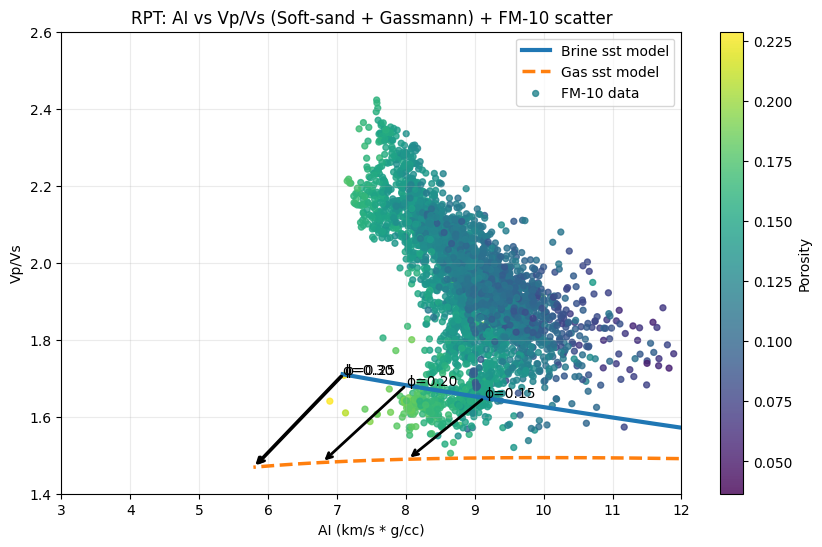

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 0) SJEKK: du må ha disse fra notebooken deres
# ============================================================
# df_logs: DataFrame med logger
# z0, z1 : top/bunn for FM-10 (samme enhet som depth i df_logs)
#
# Påkrevde kolonner i df_logs:
#   "Vp"  : m/s
#   "Vs"  : m/s
#   "DEN" : g/cc (hvis kg/m3 -> se kommentar under)
# Valgfri:
#   "phi" : porøsitet (0-1) til fargekoding

# ============================================================
# 1) ROCK PHYSICS FUNKSJONER (soft-sand + Gassmann)
# ============================================================
def hertz_mindlin(Ks, Gs, phi_c=0.36, Cn=9.0, sigma_eff_mpa=20.0, nu=0.06):
    """
    Hertz-Mindlin dry moduli at critical porosity.
    Ks, Gs in GPa. sigma_eff_mpa in MPa. Returns K_HM, G_HM in GPa.
    """
    sigma = sigma_eff_mpa / 1000.0  # MPa -> GPa

    K_hm = (((Cn**2) * ((1 - phi_c)**2) * (Gs**2) * sigma) /
            (18 * (np.pi**2) * ((1 - nu)**2)))**(1/3)

    G_hm = ((5 - 4*nu) / (5*(2 - nu))) * \
           (((3 * (Cn**2) * ((1 - phi_c)**2) * (Gs**2) * sigma) /
             (2 * (np.pi**2) * ((1 - nu)**2)))**(1/3))
    return K_hm, G_hm

def modified_hs_lower(K_hm, G_hm, Ks, Gs, phi, phi_c=0.36):
    """
    Modified lower Hashin-Shtrikman from phi_c down to phi (soft-sand trend).
    All moduli in GPa.
    """
    z = phi / phi_c

    # Bulk
    K_dry = 1.0 / ( z/(K_hm + 4.0/3.0*G_hm) + (1-z)/(Ks + 4.0/3.0*G_hm) ) - 4.0/3.0*G_hm

    # Shear
    A = (G_hm/6.0) * (9*K_hm + 8*G_hm) / (K_hm + 2*G_hm)
    G_dry = 1.0 / ( z/(G_hm + A) + (1-z)/(Gs + A) ) - A

    return K_dry, G_dry

def gassmann(K_dry, Ks, Kf, phi):
    """
    Gassmann saturation: returns K_sat (GPa). G_sat = G_dry (unchanged).
    """
    term = (1 - K_dry/Ks)**2
    denom = (phi/Kf) + ((1-phi)/Ks) - (K_dry/(Ks**2))
    return K_dry + term/denom

def vp_vs_from_moduli(K, G, rho_gcc):
    """
    K,G in GPa. rho in g/cc. Returns Vp,Vs in km/s.
    """
    K_pa = K * 1e9
    G_pa = G * 1e9
    rho_si = rho_gcc * 1000.0
    Vp = np.sqrt((K_pa + 4.0/3.0*G_pa) / rho_si) / 1000.0
    Vs = np.sqrt(G_pa / rho_si) / 1000.0
    return Vp, Vs

# ============================================================
# 2) PARAMETERE (kan tweakes)
# ============================================================
Ks = 37.0     # quartz bulk modulus (GPa)
Gs = 44.0     # quartz shear modulus (GPa)
rho_s = 2.65  # quartz density (g/cc)

phi_c = 0.36
Cn = 9.0
nu = 0.06

# Fluider (typiske)
K_brine = 2.5
rho_brine = 1.05

K_gas = 0.05
rho_gas = 0.20

# Kalibrer bounds til sand-intervallet ditt
fm10_sand = fm10[fm10["GR"] < 80]

phi_target = float(np.nanmedian(fm10_sand["phi"]))
AI_target  = float(np.nanmedian(fm10_sand["DEN"] * (fm10_sand["Vp"]/1000)))

# Bruk porøsitetsrange rundt det dere faktisk har
phi = np.linspace(max(0.03, phi_target-0.10), min(0.35, phi_target+0.10), 200)

# Sett høyere effektivspenning (flytter bounds mot høyre)
sigma_eff_mpa = 80.0

print("phi_target:", phi_target)
print("AI_target:", AI_target)
print("sigma_eff_mpa:", sigma_eff_mpa)

# ============================================================
# 3) BYGG BOUNDS (Brine/Gas) -> (AI, Vp/Vs)
# ============================================================
K_hm, G_hm = hertz_mindlin(Ks, Gs, phi_c=phi_c, Cn=Cn, sigma_eff_mpa=sigma_eff_mpa, nu=nu)
K_dry, G_dry = modified_hs_lower(K_hm, G_hm, Ks, Gs, phi, phi_c=phi_c)

# Densiteter
rho_br = (1-phi)*rho_s + phi*rho_brine
rho_ga = (1-phi)*rho_s + phi*rho_gas

# Gassmann
K_sat_br = gassmann(K_dry, Ks, K_brine, phi)
K_sat_ga = gassmann(K_dry, Ks, K_gas, phi)

Vp_br, Vs_br = vp_vs_from_moduli(K_sat_br, G_dry, rho_br)
Vp_ga, Vs_ga = vp_vs_from_moduli(K_sat_ga, G_dry, rho_ga)

AI_br = rho_br * Vp_br
AI_ga = rho_ga * Vp_ga
VpVs_br = Vp_br / Vs_br
VpVs_ga = Vp_ga / Vs_ga

# ============================================================
# 4) HENT FM-10 DATA OG REGN UT (AI, Vp/Vs)
# ============================================================
# Hvis df_logs index = depth (som dere har brukt før):
fm10 = df_logs[(df_logs.index >= z0) & (df_logs.index <= z1)].copy()

# Hvis dere i stedet har en depth-kolonne (f.eks. "Depth"):
# fm10 = df_logs[(df_logs["Depth"] >= z0) & (df_logs["Depth"] <= z1)].copy()

Vp = fm10["Vp"].astype(float).to_numpy()
Vs = fm10["Vs"].astype(float).to_numpy()
rho = fm10["DEN"].astype(float).to_numpy()

# Unit-fix (robust):
# Vp/Vs i m/s -> km/s
if np.nanmedian(Vp) > 20: Vp = Vp / 1000.0
if np.nanmedian(Vs) > 20: Vs = Vs / 1000.0

# DEN: hvis den er i kg/m3 (typisk ~2000-2700), konverter til g/cc
if np.nanmedian(rho) > 20: rho = rho / 1000.0

AI = rho * Vp
VpVs = Vp / Vs

# Farge: porøsitet hvis finnes, ellers depth (index)
if "phi" in fm10.columns:
    c = fm10["phi"].astype(float).to_numpy()
    c_label = "Porosity"
else:
    c = fm10.index.to_numpy(dtype=float)
    c_label = "Depth"

# Fjern NaN/inf
m = np.isfinite(AI) & np.isfinite(VpVs) & np.isfinite(c)
AI, VpVs, c = AI[m], VpVs[m], c[m]

# ============================================================
# 5) PLOTT: bounds + scatter (FM-10)
# ============================================================
plt.figure(figsize=(10,6))

# Bounds
plt.plot(AI_br, VpVs_br, linewidth=3, label="Brine sst model")
plt.plot(AI_ga, VpVs_ga, linestyle="--", linewidth=2.5, label="Gas sst model")

# Scatter (FM-10)
sc = plt.scatter(AI, VpVs, c=c, cmap="viridis", s=18, alpha=0.8, label="FM-10 data")
plt.colorbar(sc, label=c_label)

# Fluid trend arrows (valgfritt)
phi_marks = [0.30, 0.25, 0.20, 0.15]
for pm in phi_marks:
    i = np.argmin(np.abs(phi - pm))
    x1, y1 = AI_br[i], VpVs_br[i]
    x2, y2 = AI_ga[i], VpVs_ga[i]
    plt.annotate("", xy=(x2, y2), xytext=(x1, y1),
                 arrowprops=dict(arrowstyle="->", lw=2))
    plt.text(x1, y1, f"ϕ={pm:.2f}", fontsize=10)

# Akser/stil
plt.xlabel("AI (km/s * g/cc)")
plt.ylabel("Vp/Vs")
plt.ylim(1.4, 2.6)
plt.xlim(3, 12)
plt.grid(True, alpha=0.25)
plt.legend()
plt.title("RPT: AI vs Vp/Vs (Soft-sand + Gassmann) + FM-10 scatter")

plt.show()